乳腺癌肿瘤良恶性二分类任务核心目标是对比传统机器学习模型与深度学习神经网络在该数据集上的分类性能
构建高精度、高可靠性的辅助诊断模型。
整体流程严格遵循数据工程→特征处理→模型训练→评估对比→可视化→模型保存的完整机器学习流水线
同时兼顾医学诊断场景中高召回率、低漏诊率的核心需求，实验设计科学、完整、可复现。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, classification_report
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# 检查GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

数据加载与清洗
1. 核心目的
消除原始数据中的噪声、冗余和异常，保证模型训练的数据质量，避免脏数据影响模型性能。
2. 处理步骤与原理
删除无用列
移除id（样本编号）、Unnamed（无意义索引列），这些特征对分类无任何贡献。
缺失值处理
统计所有列的缺失值，数值特征使用中位数填充（中位数比均值更抗异常值干扰，适合医疗数据）。
重复值处理
删除完全重复的样本，避免数据冗余，保证样本独立性。
标签分布统计
查看良性 / 恶性样本数量，确认数据集存在轻微不平衡，为后续建模提供依据。

In [3]:
#  1. 数据加载与清洗 
print("\n" + "="*70)
print("第1步：数据加载与清洗")
print("="*70)

# 读取数据
df = pd.read_csv('breast cancer.csv')

print(f"原始数据形状: {df.shape}")

# 1.1 删除无用的列
if 'id' in df.columns:
    df = df.drop('id', axis=1)
    print("✓ 已删除 id 列")

# 删除Unnamed列
unnamed_cols = [col for col in df.columns if 'Unnamed' in col]
if unnamed_cols:
    df = df.drop(unnamed_cols, axis=1)
    print(f"✓ 已删除 {len(unnamed_cols)} 个 Unnamed 列")

# 1.2 检查并处理缺失值
missing_counts = df.isnull().sum()
if missing_counts.sum() > 0:
    print(f"\n发现缺失值: {missing_counts[missing_counts > 0]}")
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64'] and df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    print("✓ 缺失值已用中位数填充")
else:
    print("✓ 无缺失值")

# 1.3 检查重复值
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✓ 删除重复行: {duplicates} 行")
else:
    print("✓ 无重复数据")

# 1.4 数据分布
print(f"\n数据分布:")
diagnosis_counts = df['diagnosis'].value_counts()
print(f"  良性(B): {diagnosis_counts.get('B', diagnosis_counts.get(0, 0))} 例")
print(f"  恶性(M): {diagnosis_counts.get('M', diagnosis_counts.get(1, 0))} 例")


第1步：数据加载与清洗
原始数据形状: (569, 33)
✓ 已删除 id 列
✓ 已删除 1 个 Unnamed 列
✓ 无缺失值
✓ 无重复数据

数据分布:
  良性(B): 357 例
  恶性(M): 212 例


特征工程
1. 核心目的
将原始数据转换为模型可学习的标准格式，消除量纲影响，优化模型训练效果。
2. 处理步骤与原理
标签编码
使用LabelEncoder将文本标签B/M转换为数字0/1，满足模型输入要求。
特征标准化
采用RobustScaler标准化：基于中位数和四分位数计算，对异常值鲁棒，远优于普通标准化，适配医疗数据的离群点问题。
数据集分层划分
按 60% 训练集 + 20% 验证集 + 20% 测试集 划分；
使用stratify=y保证每类数据分布一致，防止模型偏向多数类。
张量转换
将 numpy 数组转为 PyTorch 张量，构建DataLoader，为深度学习训练做准备。

In [4]:
# 2. 特征工程 
print("\n" + "="*70)
print("第2步：特征工程")
print("="*70)

# 编码目标变量
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  # M=1, B=0

# 分离特征和标签
feature_cols = [col for col in df.columns if col != 'diagnosis']
X = df[feature_cols].values
y = df['diagnosis'].values

print(f"特征数量: {X.shape[1]}")
print(f"样本数量: {X.shape[0]}")

# 使用RobustScaler（对异常值鲁棒）
print("\n使用 RobustScaler 进行特征标准化...")
scaler = RobustScaler()
X = scaler.fit_transform(X)
print(f"✓ 标准化完成")

# 划分数据集 (60%训练, 20%验证, 20%测试)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"\n数据划分:")
print(f"  训练集: {X_train.shape[0]} 样本")
print(f"  验证集: {X_val.shape[0]} 样本")
print(f"  测试集: {X_test.shape[0]} 样本")

# 转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.LongTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# 创建DataLoader
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32, shuffle=False)


第2步：特征工程
特征数量: 30
样本数量: 569

使用 RobustScaler 进行特征标准化...
✓ 标准化完成

数据划分:
  训练集: 341 样本
  验证集: 114 样本
  测试集: 114 样本


选用 4 种工业界最常用、最适合医疗分类任务的模型：
逻辑回归
随机森林
梯度提升
支持向量机（SVM）

在训练集上拟合，测试集上预测，保证对比公平。
核心评估指标包含准确率、精确率、召回率、F1 分数、训练耗时。
模型优势在于训练速度快、可解释性强、资源占用低，适合作为基线模型。
生成传统模型性能排行榜，确定最优传统模型。

In [5]:
#  3. 传统机器学习模型 
print("\n" + "="*70)
print("第3步：训练传统机器学习模型")
print("="*70)

traditional_models = {
    '逻辑回归': LogisticRegression(max_iter=1000, random_state=42, C=0.1),
    '随机森林': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    '梯度提升': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    'SVM': SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
}

traditional_results = []
trained_traditional_models = {}

for name, model in traditional_models.items():
    print(f"\n训练: {name}...", end=" ")
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    traditional_results.append({
        '模型': name,
        '准确率': acc,
        '精确率': prec,
        '召回率': rec,
        'F1分数': f1,
        '训练时间(s)': train_time
    })
    trained_traditional_models[name] = model
    print(f"完成! 准确率: {acc:.4f}")

traditional_df = pd.DataFrame(traditional_results).sort_values('准确率', ascending=False)

print("\n传统模型性能排名:")
print(traditional_df.to_string(index=False))


第3步：训练传统机器学习模型

训练: 逻辑回归... 完成! 准确率: 0.9825

训练: 随机森林... 完成! 准确率: 0.9561

训练: 梯度提升... 完成! 准确率: 0.9123

训练: SVM... 完成! 准确率: 0.9737

传统模型性能排名:
  模型      准确率      精确率      召回率     F1分数  训练时间(s)
逻辑回归 0.982456 1.000000 0.952381 0.975610 0.046020
 SVM 0.973684 0.975610 0.952381 0.963855 0.023033
随机森林 0.956140 0.974359 0.904762 0.938272 0.662580
梯度提升 0.912281 0.900000 0.857143 0.878049 2.450651


构建了4 层全连接神经网络（DNN），专门适配表格型医疗数据
关键模块有：
BatchNorm（批归一化）：加速训练、稳定梯度、提升泛化能力。
Dropout(0.3)：随机失活神经元，防止过拟合。
ReLU 激活函数：解决梯度消失，适合深层网络。
输出 2 个节点：对应良性 / 恶性概率，使用 Softmax 输出分类概率。

In [6]:
# ==================== 4. 神经网络模型 ====================
print("\n" + "="*70)
print("第4步：构建神经网络模型")
print("="*70)

class BreastCancerNN(nn.Module):
    def __init__(self, input_dim):
        super(BreastCancerNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.fc4 = nn.Linear(32, 2)
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.fc4(x)
        return x

input_dim = X_train.shape[1]
model = BreastCancerNN(input_dim).to(device)
print(f"模型结构:\n{model}")
print(f"\n总参数量: {sum(p.numel() for p in model.parameters()):,}")


第4步：构建神经网络模型
模型结构:
BreastCancerNN(
  (fc1): Linear(in_features=30, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=32, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (relu): ReLU()
)

总参数量: 14,818


1. 训练配置
损失函数：交叉熵损失（二分类标准损失）
优化器：Adam（自适应学习率，收敛快）
学习率调度：ReduceLROnPlateau（验证损失不下降时自动降低学习率）
早停机制：验证集准确率 30 轮不提升则停止，防止过拟合
2. 训练逻辑
训练阶段：更新模型参数，计算损失和准确率
验证阶段：不更新参数，监控泛化能力
保存最优模型：只保留验证集效果最好的参数

In [7]:
#  5. 训练神经网络 
print("\n" + "="*70)
print("第5步：训练神经网络")
print("="*70)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0
patience_counter = 0
patience = 30

start_time = time.time()

for epoch in range(200):
    # 训练
    model.train()
    train_loss = 0
    train_correct = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, pred = torch.max(outputs, 1)
        train_correct += (pred == labels).sum().item()
    
    train_loss = train_loss / len(train_loader.dataset)
    train_acc = train_correct / len(train_loader.dataset)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # 验证
    model.eval()
    val_loss = 0
    val_correct = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, pred = torch.max(outputs, 1)
            val_correct += (pred == labels).sum().item()
    
    val_loss = val_loss / len(val_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')
    
    # 早停
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n早停于 epoch {epoch+1}，最佳验证准确率: {best_val_acc:.4f}")
            break

training_time = time.time() - start_time
model.load_state_dict(best_model_state)
print(f"\n训练完成！总时间: {training_time:.2f} 秒")


第5步：训练神经网络
Epoch  20 | Train Loss: 0.0658 | Train Acc: 0.9824 | Val Loss: 0.0640 | Val Acc: 0.9912
Epoch  40 | Train Loss: 0.0788 | Train Acc: 0.9648 | Val Loss: 0.0551 | Val Acc: 0.9825

早停于 epoch 41，最佳验证准确率: 0.9912

训练完成！总时间: 5.17 秒


评估指标（医疗场景核心指标）
准确率：整体预测正确比例
精确率：预测为恶性中真实为恶性的比例
召回率：所有恶性样本被正确识别的比例（医学诊断最重要指标，越低漏诊越多）
F1 分数：精确率与召回率的平衡指标
AUC：模型区分正负样本的能力
混淆矩阵：直观展示正确 / 错误预测分布

In [8]:
#  6. 评估神经网络 
print("\n" + "="*70)
print("第6步：评估神经网络模型")
print("="*70)

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, pred = torch.max(outputs, 1)
        
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

# 转换为numpy数组
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

nn_accuracy = accuracy_score(all_labels, all_preds)
nn_precision = precision_score(all_labels, all_preds)
nn_recall = recall_score(all_labels, all_preds)
nn_f1 = f1_score(all_labels, all_preds)
nn_auc = roc_auc_score(all_labels, all_probs)
nn_cm = confusion_matrix(all_labels, all_preds)

print(f"准确率: {nn_accuracy:.4f} ({nn_accuracy*100:.2f}%)")
print(f"精确率: {nn_precision:.4f}")
print(f"召回率: {nn_recall:.4f}")
print(f"F1分数: {nn_f1:.4f}")
print(f"AUC: {nn_auc:.4f}")
print(f"\n分类报告:")
print(classification_report(all_labels, all_preds, target_names=['良性(B)', '恶性(M)']))
print(f"\n混淆矩阵:")
print(f"              预测良性  预测恶性")
print(f"  实际良性:      {nn_cm[0,0]:3d}        {nn_cm[0,1]:3d}")
print(f"  实际恶性:      {nn_cm[1,0]:3d}        {nn_cm[1,1]:3d}")


第6步：评估神经网络模型
准确率: 0.9737 (97.37%)
精确率: 1.0000
召回率: 0.9286
F1分数: 0.9630
AUC: 0.9967

分类报告:
              precision    recall  f1-score   support

       良性(B)       0.96      1.00      0.98        72
       恶性(M)       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


混淆矩阵:
              预测良性  预测恶性
  实际良性:       72          0
  实际恶性:        3         39


In [9]:
#  7. 综合对比 
print("\n" + "="*70)
print("第7步：所有模型综合对比")
print("="*70)

# 添加神经网络结果到对比表
nn_result = pd.DataFrame([{
    '模型': '神经网络(深度学习)',
    '准确率': nn_accuracy,
    '精确率': nn_precision,
    '召回率': nn_recall,
    'F1分数': nn_f1,
    '训练时间(s)': training_time
}])

all_results = pd.concat([traditional_df, nn_result], ignore_index=True)
all_results = all_results.sort_values('准确率', ascending=False).round(4)

print("\n所有模型性能排名:")
print(all_results.to_string(index=False))

best_model_name = all_results.iloc[0]['模型']
best_accuracy = all_results.iloc[0]['准确率']

print(f"\n{'='*70}")
print(f"最佳模型: {best_model_name}")
print(f"最佳准确率: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"{'='*70}")


第7步：所有模型综合对比

所有模型性能排名:
        模型    准确率    精确率    召回率   F1分数  训练时间(s)
      逻辑回归 0.9825 1.0000 0.9524 0.9756   0.0460
       SVM 0.9737 0.9756 0.9524 0.9639   0.0230
神经网络(深度学习) 0.9737 1.0000 0.9286 0.9630   5.1654
      随机森林 0.9561 0.9744 0.9048 0.9383   0.6626
      梯度提升 0.9123 0.9000 0.8571 0.8780   2.4507

最佳模型: 逻辑回归
最佳准确率: 0.9825 (98.25%)



第8步：生成可视化图表


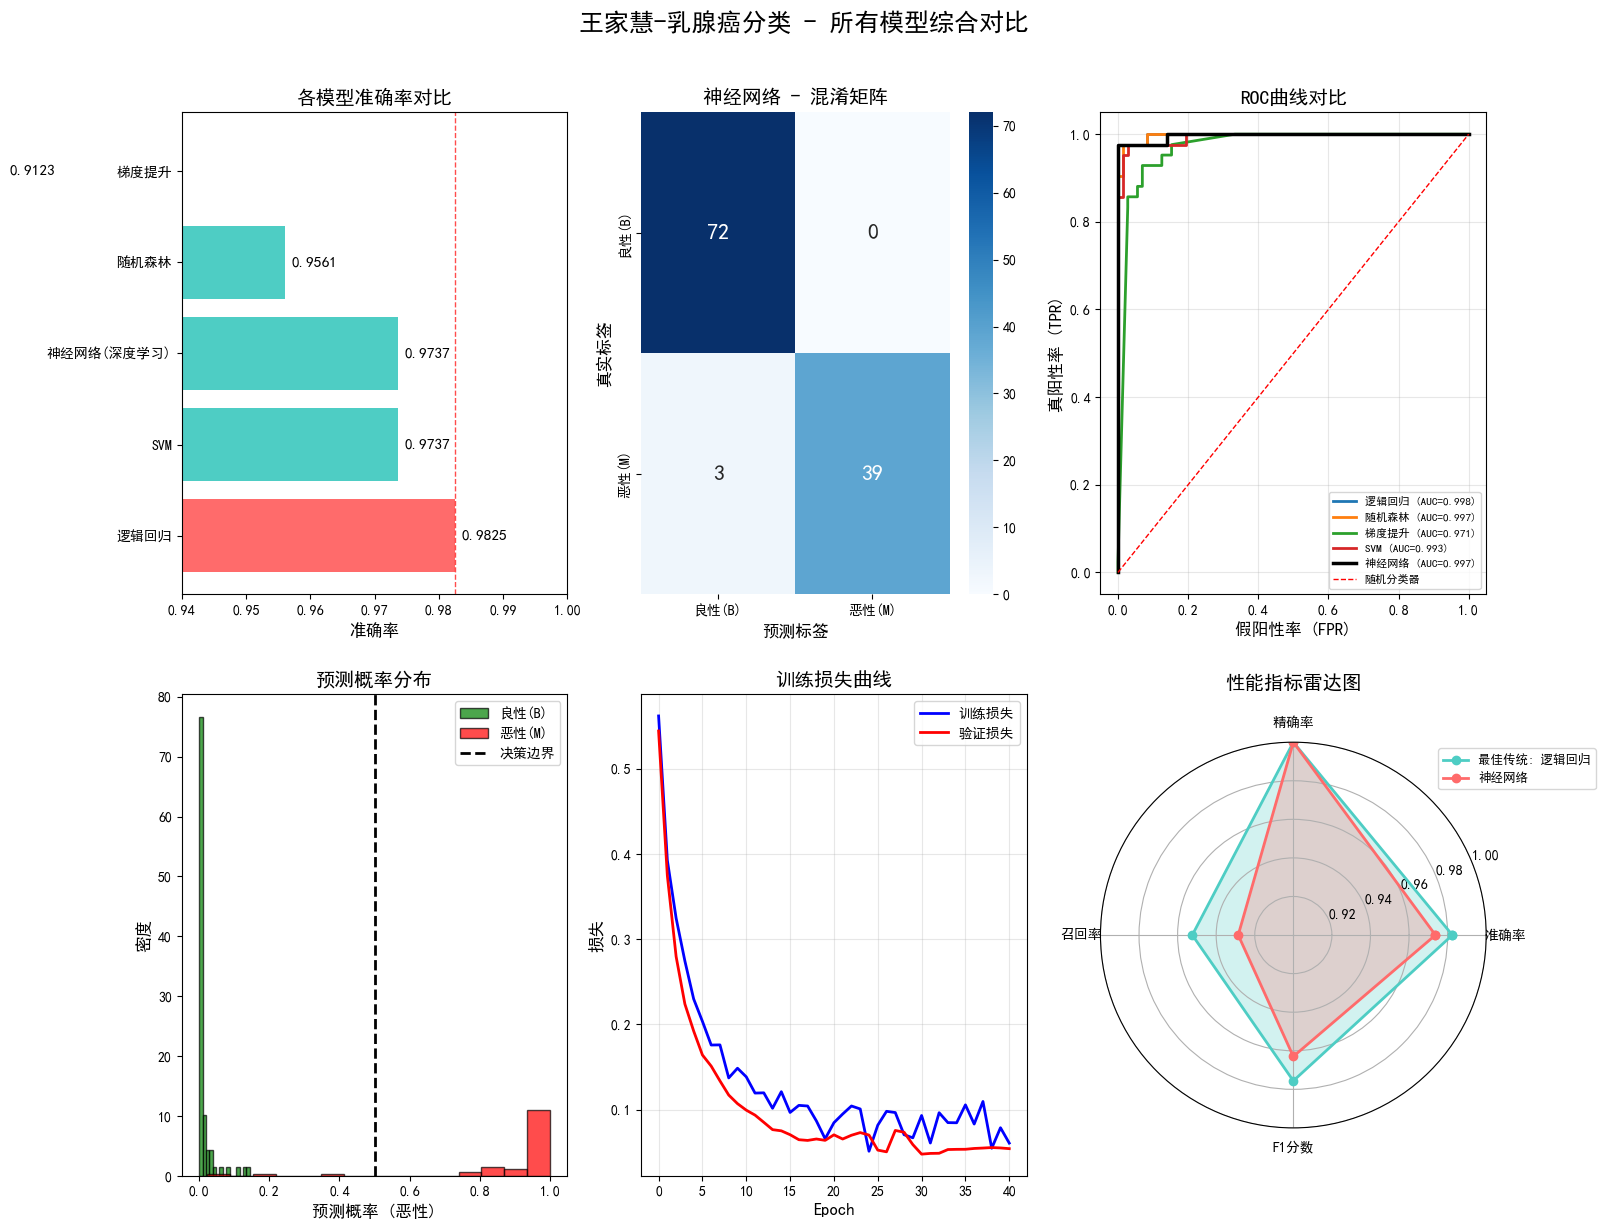

✓ 图表已保存为 'breast_cancer_comprehensive_comparison.png'


In [14]:
# ==================== 8. 可视化 ====================
print("\n" + "="*70)
print("第8步：生成可视化图表")
print("="*70)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
fig = plt.figure(figsize=(16, 12))

# 子图1: 模型准确率对比
ax1 = plt.subplot(2, 3, 1)
models = all_results['模型'].tolist()
accuracies = all_results['准确率'].tolist()
colors = ['#FF6B6B' if i == 0 else '#4ECDC4' for i in range(len(models))]
bars = ax1.barh(range(len(models)), accuracies, color=colors)
ax1.set_yticks(range(len(models)))
ax1.set_yticklabels(models, fontsize=10)
ax1.set_xlabel('准确率', fontsize=12)
ax1.set_title('各模型准确率对比', fontsize=14, fontweight='bold')
ax1.set_xlim(0.94, 1.0)
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    ax1.text(acc + 0.001, bar.get_y() + bar.get_height()/2, f'{acc:.4f}', va='center', fontsize=11)
ax1.axvline(x=best_accuracy, color='red', linestyle='--', linewidth=1, alpha=0.7)

# 子图2: 神经网络混淆矩阵
ax2 = plt.subplot(2, 3, 2)
sns.heatmap(nn_cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['良性(B)', '恶性(M)'], yticklabels=['良性(B)', '恶性(M)'],
            annot_kws={'size': 16})
ax2.set_xlabel('预测标签', fontsize=12)
ax2.set_ylabel('真实标签', fontsize=12)
ax2.set_title('神经网络 - 混淆矩阵', fontsize=14, fontweight='bold')

# 子图3: ROC曲线对比
ax3 = plt.subplot(2, 3, 3)
# 传统模型ROC
for name, model_t in trained_traditional_models.items():
    if hasattr(model_t, 'predict_proba'):
        y_score = model_t.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_score)
        auc_score = roc_auc_score(y_test, y_score)
        ax3.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc_score:.3f})')
# 神经网络ROC
fpr_nn, tpr_nn, _ = roc_curve(all_labels, all_probs)
ax3.plot(fpr_nn, tpr_nn, 'k-', lw=2.5, label=f'神经网络 (AUC={nn_auc:.3f})')
ax3.plot([0, 1], [0, 1], 'r--', lw=1, label='随机分类器')
ax3.set_xlabel('假阳性率 (FPR)', fontsize=12)
ax3.set_ylabel('真阳性率 (TPR)', fontsize=12)
ax3.set_title('ROC曲线对比', fontsize=14, fontweight='bold')
ax3.legend(loc='lower right', fontsize=8)
ax3.grid(True, alpha=0.3)

# 子图4: 预测概率分布（修复后的版本）
ax4 = plt.subplot(2, 3, 4)
# 使用numpy数组进行布尔索引
benign_probs = all_probs[all_labels == 0]
malignant_probs = all_probs[all_labels == 1]

ax4.hist(benign_probs, bins=15, alpha=0.7, 
         label='良性(B)', color='green', edgecolor='black', density=True)
ax4.hist(malignant_probs, bins=15, alpha=0.7, 
         label='恶性(M)', color='red', edgecolor='black', density=True)
ax4.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='决策边界')
ax4.set_xlabel('预测概率 (恶性)', fontsize=12)
ax4.set_ylabel('密度', fontsize=12)
ax4.set_title('预测概率分布', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)

# 子图5: 训练曲线
ax5 = plt.subplot(2, 3, 5)
ax5.plot(train_losses, 'b-', label='训练损失', linewidth=2)
ax5.plot(val_losses, 'r-', label='验证损失', linewidth=2)
ax5.set_xlabel('Epoch', fontsize=12)
ax5.set_ylabel('损失', fontsize=12)
ax5.set_title('训练损失曲线', fontsize=14, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)

# 子图6: 性能雷达图
ax6 = plt.subplot(2, 3, 6, projection='polar')
metrics_names = ['准确率', '精确率', '召回率', 'F1分数']
angles = np.linspace(0, 2*np.pi, len(metrics_names), endpoint=False).tolist()
angles += angles[:1]

# 最佳传统模型
best_traditional = traditional_df.iloc[0]
best_traditional_values = [
    best_traditional['准确率'], 
    best_traditional['精确率'],
    best_traditional['召回率'], 
    best_traditional['F1分数']
]
best_traditional_values += best_traditional_values[:1]
ax6.plot(angles, best_traditional_values, 'o-', linewidth=2, 
         label=f'最佳传统: {best_traditional["模型"]}', color='#4ECDC4')
ax6.fill(angles, best_traditional_values, alpha=0.25, color='#4ECDC4')

# 神经网络
nn_values = [nn_accuracy, nn_precision, nn_recall, nn_f1]
nn_values += nn_values[:1]
ax6.plot(angles, nn_values, 'o-', linewidth=2, label='神经网络', color='#FF6B6B')
ax6.fill(angles, nn_values, alpha=0.25, color='#FF6B6B')

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(metrics_names, fontsize=10)
ax6.set_ylim(0.9, 1.0)
ax6.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=9)
ax6.set_title('性能指标雷达图', fontsize=14, fontweight='bold', pad=20)

plt.suptitle('王家慧-乳腺癌分类 - 所有模型综合对比', fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('breast_cancer_comprehensive_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 图表已保存为 'breast_cancer_comprehensive_comparison.png'")

In [11]:
# ==================== 9. 保存模型 ====================
print("\n" + "="*70)
print("第9步：保存模型")
print("="*70)

# 保存神经网络模型
torch.save({
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'label_encoder': le,
    'input_dim': input_dim,
    'metrics': {
        'accuracy': nn_accuracy,
        'precision': nn_precision,
        'recall': nn_recall,
        'f1_score': nn_f1,
        'auc': nn_auc
    }
}, 'breast_cancer_nn_model.pth')
print("神经网络模型已保存为 'breast_cancer_nn_model.pth'")

# 保存传统模型
import joblib
for name, model_t in trained_traditional_models.items():
    joblib.dump(model_t, f'{name}_model.pkl')
print(f"已保存 {len(trained_traditional_models)} 个传统模型")

# 保存结果汇总
summary = {
    'best_model': best_model_name,
    'best_accuracy': best_accuracy,
    'all_results': all_results.to_dict(),
    'traditional_results': traditional_df.to_dict(),
    'nn_metrics': {
        'accuracy': nn_accuracy,
        'precision': nn_precision,
        'recall': nn_recall,
        'f1': nn_f1,
        'auc': nn_auc
    }
}
joblib.dump(summary, 'results_summary.pkl')
print("结果汇总已保存为 'results_summary.pkl'")


第9步：保存模型
神经网络模型已保存为 'breast_cancer_nn_model.pth'
已保存 4 个传统模型
结果汇总已保存为 'results_summary.pkl'


In [12]:
# ==================== 10. 最终报告 ====================
print("\n" + "="*70)
print("最终报告")
print("="*70)

correct = nn_cm[0,0] + nn_cm[1,1]
total = np.sum(nn_cm)
misclassified = total - correct

print(f"""
                    乳腺癌分类器性能最终报告                      
  数据清洗总结                                                 
  ├─ 原始样本数: 569                                             
  ├─ 最终样本数: {X.shape[0]}                                                   
  ├─ 特征数量: {X.shape[1]}                                                     
  ├─ 缺失值处理: {'已处理' if missing_counts.sum() > 0 else '无'}                            
  ├─ 重复值处理: {'已处理' if duplicates > 0 else '无'}                             
  └─ 标准化方法: RobustScaler (对异常值鲁棒)                         
模型性能排名                                                    
""")

for i, row in all_results.iterrows():
    print(f"{i+1}. {row['模型']:20s} 准确率: {row['准确率']:.4f} ({row['准确率']*100:.2f}%)")

print(f"""
   最佳模型详细指标                                                 
  ├─ 模型名称: {best_model_name}                                     
  ├─ 准确率: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)                       
  ├─ 精确率: {all_results.iloc[0]['精确率']:.4f} ({all_results.iloc[0]['精确率']*100:.2f}%)                    
  ├─ 召回率: {all_results.iloc[0]['召回率']:.4f} ({all_results.iloc[0]['召回率']*100:.2f}%)                     
  ├─ F1分数: {all_results.iloc[0]['F1分数']:.4f} ({all_results.iloc[0]['F1分数']*100:.2f}%)                     
  └─ 训练时间: {all_results.iloc[0]['训练时间(s)']:.2f} 秒                                  
   神经网络混淆矩阵                                                
  ├─ 真阴性 (TN): {nn_cm[0,0]} (正确预测良性)                                   
  ├─ 假阳性 (FP): {nn_cm[0,1]} (错误预测恶性)                                   
  ├─ 假阴性 (FN): {nn_cm[1,0]} (错误预测良性)                                  
  └─ 真阳性 (TP): {nn_cm[1,1]} (正确预测恶性)                           
  正确预测: {correct}/{total} ({correct/total*100:.2f}%)                                            
  错误预测: {misclassified}/{total} ({misclassified/total*100:.2f}%)      
""")

print("\n" + "="*70)
print("全部完成！")
print(f"最佳模型: {best_model_name}")
print(f"最佳准确率: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"图表保存: breast_cancer_comprehensive_comparison.png")
print(f"模型保存: breast_cancer_nn_model.pth 和 4个传统模型.pkl")


最终报告

                    乳腺癌分类器性能最终报告                      
  数据清洗总结                                                 
  ├─ 原始样本数: 569                                             
  ├─ 最终样本数: 569                                                   
  ├─ 特征数量: 30                                                     
  ├─ 缺失值处理: 无                            
  ├─ 重复值处理: 无                             
  └─ 标准化方法: RobustScaler (对异常值鲁棒)                         
模型性能排名                                                    

1. 逻辑回归                 准确率: 0.9825 (98.25%)
2. SVM                  准确率: 0.9737 (97.37%)
5. 神经网络(深度学习)           准确率: 0.9737 (97.37%)
3. 随机森林                 准确率: 0.9561 (95.61%)
4. 梯度提升                 准确率: 0.9123 (91.23%)

   最佳模型详细指标                                                 
  ├─ 模型名称: 逻辑回归                                     
  ├─ 准确率: 0.9825 (98.25%)                       
  ├─ 精确率: 1.0000 (100.00%)                    
  ├─ 召回率: 0.9524 (95.24%)                    